In [2]:
import numpy as np
import enum
import time
from threading import Thread
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

In [2]:
class MessageStatus(enum.Enum):
    OK = enum.auto()
    LOST = enum.auto()

In [3]:
class Message:
    number = -1
    real_number = -1
    data = ""
    status = MessageStatus.OK

    def __init__(self):
        pass

    def copy(self):
        msg = Message()
        msg.number = self.number
        msg.data = self.data
        msg.status = self.status
        return msg

    def __str__(self):
        return f"({self.real_number}({self.number}), {self.data}, {self.status})"

In [4]:
class MsgQueue:
    def __init__(self, loss_probability=0.3):
        self.msg_queue = []
        self.loss_probability = loss_probability
        pass

    def has_msg(self):
        if len(self.msg_queue) <= 0:
            return False
        else:
            return True

    def get_message(self):
        if self.has_msg():
            result = self.msg_queue[0]
            self.msg_queue.pop(0)
            return result

    def send_message(self, msg):
        tmp_msg = self.emulating_channel_problems(msg)
        self.msg_queue.append(tmp_msg)

    def emulating_channel_problems(self, msg):
        val = np.random.rand()
        if val <= self.loss_probability:
            msg.status = MessageStatus.LOST

        return msg

    def __str__(self):
        res_str = "[ "
        for i in range(len(self.msg_queue)):
            msg = self.msg_queue[i]
            res_str += f"({msg.number}, {msg.status}), "

        res_str += "]"
        return res_str

In [5]:
class GBN_sender:
    def __init__ (self, answer_msg_queue, send_msg_queue, posted_msgs):
        self.answer_msg_queue = answer_msg_queue
        self.send_msg_queue = send_msg_queue
        self.posted_msgs = posted_msgs

    def __call__(self, window_size, max_number, timeout):
        curr_number = 0
        last_ans_number = -1
        start_time = time.time()
        while last_ans_number < max_number:
            expected_number = (last_ans_number + 1) % window_size

            if self.answer_msg_queue.has_msg():
                ans = self.answer_msg_queue.get_message()
                if ans.number == expected_number:
                    # последовательное подтверждение пакетов - всё ок
                    last_ans_number += 1
                    start_time = time.time()
                else:
                    # произошёл сбой, нужно повторить отправку сообщений с последнего подтверждённого
                    curr_number = last_ans_number + 1

            # долго нет ответа с последнего подтверждения
            if time.time() - start_time > timeout:
                # произошёл сбой, нужно повторить отправку сообщений с последнего подтверждённого
                curr_number = last_ans_number + 1
                start_time = time.time()

            if (curr_number < last_ans_number + window_size) and (curr_number <= max_number):
                #   отправляем не более window_size сообщений наперёд
                k = curr_number % window_size
                msg = Message()
                msg.number = k
                msg.real_number = curr_number
                self.send_msg_queue.send_message(msg)
                self.posted_msgs.append(f"{curr_number}({k})")

                curr_number += 1

        msg = Message()
        msg.data = "STOP"
        self.send_msg_queue.send_message(msg)


class GBN_receiver:
    def __init__ (self, answer_msg_queue, send_msg_queue, received_msgs):
        self.answer_msg_queue = answer_msg_queue
        self.send_msg_queue = send_msg_queue
        self.received_msgs = received_msgs

    def __call__(self, window_size):
        expected_number = 0
        while True:
            if self.send_msg_queue.has_msg():
                curr_msg = self.send_msg_queue.get_message()
                #print(f"res: {curr_msg} | {expected_number}")
                if curr_msg.data == "STOP":
                    break

                if curr_msg.status == MessageStatus.LOST:
                    continue

                if curr_msg.number == expected_number:
                    ans = Message()
                    ans.number = curr_msg.number
                    self.answer_msg_queue.send_message(ans)

                    self.received_msgs.append(f"{curr_msg.real_number}({curr_msg.number})")
                    expected_number = (expected_number + 1) % window_size

                else:
                    continue

In [6]:
class SRP_sender:
    def __init__ (self, answer_msg_queue, send_msg_queue, posted_msgs):
        self.answer_msg_queue = answer_msg_queue
        self.send_msg_queue = send_msg_queue
        self.posted_msgs = posted_msgs

    def __call__(self, window_size, max_number, timeout):
        class WndMsgStatus(enum.Enum):
            BUSY = enum.auto()
            NEED_REPEAT = enum.auto()
            CAN_BE_USED = enum.auto()

        class WndNode:
            def __init__(self, number):
                self.status = WndMsgStatus.NEED_REPEAT
                self.time = 0
                self.number = number
                pass

            def __str__(self):
                return f"( {self.number}, {self.status}, {self.time})"

        wnd_nodes = [WndNode(i) for i in range(window_size)]

        ans_count = 0

        while ans_count < max_number:

            res_str = "["
            for i in range(window_size):
                res_str += wnd_nodes[i].__str__()
            res_str += "]"

            if self.answer_msg_queue.has_msg():
                ans = self.answer_msg_queue.get_message()
                ans_count += 1
                wnd_nodes[ans.number].status = WndMsgStatus.CAN_BE_USED

            # долго нет ответа с последнего подтверждения
            curr_time = time.time()
            for i in range(window_size):
                if wnd_nodes[i].number > max_number:
                    continue

                send_time = wnd_nodes[i].time
                if curr_time - send_time > timeout:
                    # произошёл сбой, нужно повторить отправку этого сообщения
                    wnd_nodes[i].status = WndMsgStatus.NEED_REPEAT

            # отправляем новые или повторяем, если необходимо
            for i in range(window_size):
                if wnd_nodes[i].number > max_number:
                    continue

                if wnd_nodes[i].status == WndMsgStatus.BUSY:
                    continue

                elif wnd_nodes[i].status == WndMsgStatus.NEED_REPEAT:
                    wnd_nodes[i].status = WndMsgStatus.BUSY
                    wnd_nodes[i].time = time.time()

                    msg = Message()
                    msg.number = i
                    msg.real_number = wnd_nodes[i].number
                    self.send_msg_queue.send_message(msg)
                    self.posted_msgs.append(f"{msg.real_number}({msg.number})")

                elif wnd_nodes[i].status == WndMsgStatus.CAN_BE_USED:
                    wnd_nodes[i].status = WndMsgStatus.BUSY
                    wnd_nodes[i].time = time.time()
                    wnd_nodes[i].number = wnd_nodes[i].number + window_size

                    if wnd_nodes[i].number > max_number:
                        continue

                    msg = Message()
                    msg.number = i
                    msg.real_number = wnd_nodes[i].number
                    self.send_msg_queue.send_message(msg)
                    self.posted_msgs.append(f"{msg.real_number}({msg.number})")

        msg = Message()
        msg.data = "STOP"
        self.send_msg_queue.send_message(msg)


class SRP_receiver:
    def __init__ (self, answer_msg_queue, send_msg_queue, received_msgs):
        self.answer_msg_queue = answer_msg_queue
        self.send_msg_queue = send_msg_queue
        self.received_msgs = received_msgs

    def __call__(self, window_size):
        while True:
            if self.send_msg_queue.has_msg():
                curr_msg = self.send_msg_queue.get_message()

                if curr_msg.data == "STOP":
                    break

                if curr_msg.status == MessageStatus.LOST:
                    continue

                ans = Message()
                ans.number = curr_msg.number
                self.answer_msg_queue.send_message(ans)
                self.received_msgs.append(f"{curr_msg.real_number}({curr_msg.number})")

In [ ]:
send_msg_queue = MsgQueue()
answer_msg_queue = MsgQueue()

posted_msgs = []
received_msgs = []


def losing_test():
    global send_msg_queue
    global answer_msg_queue
    global posted_msgs
    global received_msgs

    window_size = 3
    timeout = 0.2
    max_number = 100
    loss_probability_arr = np.linspace(0, 0.9, 9)
    protocol_arr = ["GBN", "SRP"]

    print("w\t| GBN\t\t| SRP")
    print(" \t| t\t| k\t| t\t| k")

    gbn_time = []
    srp_time = []
    gbn_k = []
    srp_k = []
    for p in loss_probability_arr:
        table_row = f"{p:.1f}"
        send_msg_queue = MsgQueue(p)
        answer_msg_queue = MsgQueue(p)
        posted_msgs = []
        received_msgs = []

        for protocol in protocol_arr:
            if protocol == "GBN":
                sender_th = Thread(target=GBN_sender(answer_msg_queue, send_msg_queue, posted_msgs), args=(window_size, max_number, timeout))
                receiver_th = Thread(target=GBN_receiver(answer_msg_queue, send_msg_queue, received_msgs), args=(window_size,))
            elif protocol == "SRP":
                sender_th = Thread(target=SRP_sender(answer_msg_queue, send_msg_queue, posted_msgs), args=(window_size, max_number, timeout))
                receiver_th = Thread(target=SRP_receiver(answer_msg_queue, send_msg_queue, received_msgs), args=(window_size,))

            timer_start = time.time()
            sender_th.start()
            receiver_th.start()

            sender_th.join()
            receiver_th.join()
            timer_end = time.time()

            k = len(received_msgs) / len(posted_msgs)
            elapsed = timer_end - timer_start

            table_row += f"\t| {elapsed:2.2f}\t| {k:.2f}"
            if protocol == "GBN":
                gbn_time.append(elapsed)
                gbn_k.append(k)
            else:
                srp_time.append(elapsed)
                srp_k.append(k)

        print(table_row)

    fig, ax = plt.subplots()
    ax.plot(loss_probability_arr, gbn_k, label="Go-Back-N")
    ax.plot(loss_probability_arr, srp_k, label="Selective repeat")
    ax.set_xlabel('вероятность потери пакета')
    ax.set_ylabel('коэф. эффективности')
    ax.legend()
    ax.grid()
    fig.show()

    fig, ax = plt.subplots()
    ax.plot(loss_probability_arr, gbn_time, label="Go-Back-N")
    ax.plot(loss_probability_arr, srp_time, label="Selective repeat")
    ax.set_xlabel('вероятность потери пакета')
    ax.set_ylabel('время передачи, с')
    ax.legend()
    ax.grid()
    fig.show()

    print("p")
    print(loss_probability_arr)
    print("GBN")
    print(gbn_time)
    print("time")
    print("k")
    print(gbn_k)

    print("SRP")
    print(srp_time)
    print("time")
    print("k")
    print(srp_k)


In [1]:
losing_test()

NameError: name 'losing_test' is not defined

In [ ]:
def window_test():
    global send_msg_queue
    global answer_msg_queue
    global posted_msgs
    global received_msgs

    window_size_arr = range(2, 16)
    timeout = 0.2
    max_number = 100
    loss_probability_arr = 0.2
    send_msg_queue = MsgQueue(loss_probability_arr)
    answer_msg_queue = MsgQueue(loss_probability_arr)
    protocol_arr = ["GBN", "SRP"]

    print("w\t| GBN\t\t| SRP")
    print(" \t| t\t| k\t| t\t| k")

    gbn_time = []
    srp_time = []
    gbn_k = []
    srp_k = []
    for window_size in window_size_arr:
        table_row = f"{window_size:}"

        posted_msgs = []
        received_msgs = []

        for protocol in protocol_arr:
            
            timer_start = time.time()
            for i in range(10):
                if protocol == "GBN":
                    sender_th = Thread(target=GBN_sender(answer_msg_queue, send_msg_queue, posted_msgs), args=(window_size, max_number, timeout))
                    receiver_th = Thread(target=GBN_receiver(answer_msg_queue, send_msg_queue, received_msgs), args=(window_size,))
                elif protocol == "SRP":
                    sender_th = Thread(target=SRP_sender(answer_msg_queue, send_msg_queue, posted_msgs), args=(window_size, max_number, timeout))
                    receiver_th = Thread(target=SRP_receiver(answer_msg_queue, send_msg_queue, received_msgs), args=(window_size,))

                sender_th.start()
                receiver_th.start()

                sender_th.join()
                receiver_th.join()
            timer_end = time.time()

            k = len(received_msgs) / len(posted_msgs) / 10
            elapsed = (timer_end - timer_start) / 10

            table_row += f"\t| {elapsed:2.2f}\t| {k:.2f}"
            if protocol == "GBN":
                gbn_time.append(elapsed)
                gbn_k.append(k)
            else:
                srp_time.append(elapsed)
                srp_k.append(k)

        print(table_row)

    fig, ax = plt.subplots()
    ax.plot(window_size_arr, gbn_k, label="Go-Back-N")
    ax.plot(window_size_arr, srp_k, label="Selective repeat")
    ax.set_xlabel('размер окна')
    ax.set_ylabel('коэф. эффективности')
    ax.legend()
    ax.grid()
    fig.show()

    fig, ax = plt.subplots()
    ax.plot(window_size_arr, gbn_time, label="Go-Back-N")
    ax.plot(window_size_arr, srp_time, label="Selective repeat")
    ax.set_xlabel('размер окна')
    ax.set_ylabel('время передачи, с')
    ax.legend()
    ax.grid()
    fig.show()


    print("w")
    print(window_size_arr)
    print("GBN")
    print(gbn_time)
    print("time")
    print("k")
    print(gbn_k)

    print("SRP")
    print(srp_time)
    print("time")
    print("k")
    print(srp_k)

w	| GBN		| SRP
 	| t	| k	| t	| k
2	| 8.16	| 0.08	| 4.78	| 0.08
3	| 5.88	| 0.07	| 3.05	| 0.08
4	| 6.44	| 0.06	| 2.45	| 0.07
5	| 5.69	| 0.05	| 2.10	| 0.06
6	| 5.92	| 0.05	| 2.00	| 0.06
7	| 6.01	| 0.04	| 1.74	| 0.05
8	| 5.33	| 0.04	| 1.54	| 0.05
9	| 5.92	| 0.03	| 1.39	| 0.05
10	| 6.21	| 0.03	| 1.37	| 0.04
w
range(2, 11)
GBN
[8.158005452156067, 5.88180365562439, 6.4360088348388675, 5.690305018424988, 5.922257399559021, 6.007652711868286, 5.334915351867676, 5.919113755226135, 6.211015391349792]
time
k
[0.08003169572107766, 0.07092696629213482, 0.05699774266365688, 0.05307409353652128, 0.046118721461187215, 0.04084108370400323, 0.03956130043086565, 0.03452991452991453, 0.02998812351543943]
SRP
[4.775336360931396, 3.0481629848480223, 2.4542368173599245, 2.103944730758667, 1.9955437421798705, 1.7407254457473755, 1.5424455165863038, 1.3884063720703126, 1.3716489791870117]
time
k
[0.07942338072669827, 0.07560150375939849, 0.06672196416721964, 0.06391096979332274, 0.05849331006399069, 0.054042438

C:\Users\Daniil\AppData\Local\Temp\ipykernel_26248\1505696618.py:66: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
C:\Users\Daniil\AppData\Local\Temp\ipykernel_26248\1505696618.py:75: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


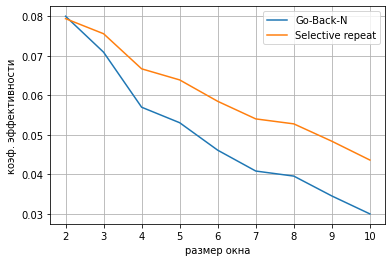

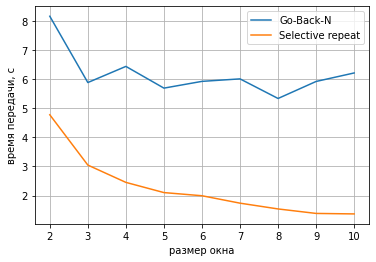

In [12]:
window_test()

w	| GBN		| SRP
 	| t	| k	| t	| k
2	| 8.06	| 0.81	| 4.60	| 0.81
3	| 6.57	| 0.69	| 4.07	| 0.70
4	| 6.53	| 0.59	| 2.43	| 0.67
5	| 5.42	| 0.55	| 2.05	| 0.64
6	| 4.74	| 0.52	| 2.39	| 0.61
7	| 5.88	| 0.42	| 1.45	| 0.55
8	| 5.76	| 0.38	| 1.60	| 0.53
9	| 5.35	| 0.37	| 1.72	| 0.49
10	| 4.19	| 0.42	| 1.31	| 0.56
w
range(2, 11)
GBN
[8.059666156768799, 6.569637060165405, 6.525664329528809, 5.418843507766724, 4.735393762588501, 5.883633852005005, 5.760002613067627, 5.3542327880859375, 4.186209201812744]
time
k
[0.808, 0.6917808219178082, 0.5906432748538012, 0.5519125683060109, 0.5153061224489796, 0.4190871369294606, 0.3840304182509506, 0.36594202898550726, 0.4225941422594142]
SRP
[4.596148729324341, 4.073107957839966, 2.4322290420532227, 2.0504980087280273, 2.385965347290039, 1.4483704566955566, 1.6011486053466797, 1.7235188484191895, 1.3104703426361084]
time
k
[0.8112449799196787, 0.6979166666666666, 0.674496644295302, 0.643312101910828, 0.6066066066066066, 0.5504087193460491, 0.5274151436031331, 

C:\Users\Daniil\AppData\Local\Temp\ipykernel_26248\3313275333.py:64: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
C:\Users\Daniil\AppData\Local\Temp\ipykernel_26248\3313275333.py:73: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


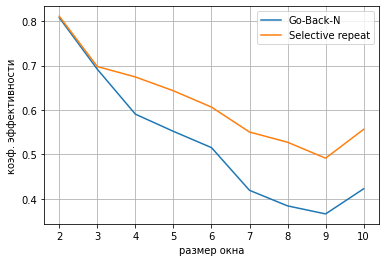

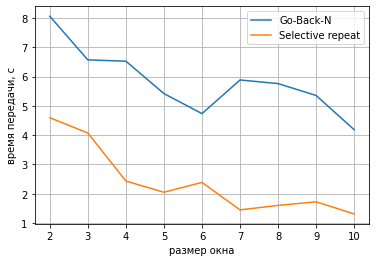

In [8]:
window_test()